# CartSense — Purchase-Intent Prediction for E-Commerce Revenue Recovery
### COM763 Advanced Machine Learning — Task 1

**Problem.** ~85% of e-commerce sessions end without a purchase. Retention budget (discount codes,
live-chat agents, exit-intent offers) is finite, so it must be aimed at the *winnable* sessions —
the ones that are hesitating, not the ones that were never going to buy and not the ones already
converting on their own.

**Task.** Binary classification. Input = 17 session-level signals available in real time from
Google Analytics. Output = P(purchase) for the live session, converted to an intervene / don't-intervene
decision at a tuned threshold.

**Dataset.** UCI Machine Learning Repository — *Online Shoppers Purchasing Intention Dataset*
(Sakar & Kastro, 2018; ID 468). 12,330 sessions × 18 attributes, one session per user over one year.

**Primary metric.** PR-AUC and F1 on the positive class — **not accuracy**. With a 15.5% positive
rate, a model that predicts "no purchase" for every session already scores 84.5% accuracy while
being commercially worthless.

**Notebook order:** 1 Load → 2 Clean → 3 EDA → 4 Train → 5 Evaluate → 6 Save model.pkl

## Setup

In [1]:

!pip -q install scikit-learn==1.8.0

import warnings, json, pickle, os, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import sklearn

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

RS = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.titleweight": "bold"})
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.5 MB/s eta 0:00:00
scikit-learn 1.8.0 | pandas 2.2.2 | numpy 2.0.2


---
## Section 1 — Load Dataset

Pulled straight from the UCI repository therefore the notebook is reproducible.
A local `dataset.csv` fallback keeps it working offline / on Streamlit Cloud.

In [2]:
URL = "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"

try:
    df = pd.read_csv(URL, compression="zip")
    print("Loaded directly from UCI.")
except Exception as e:
    print("UCI fetch failed (%s) — using local dataset.csv" % type(e).__name__)
    df = pd.read_csv("dataset.csv")

df.to_csv("dataset.csv", index=False)
print("Shape:", df.shape)
df.head()

Loaded directly from UCI.
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()
print("\nTarget balance:")
print(df["Revenue"].value_counts())
print("\nPositive rate: %.4f  (a majority-class baseline would score %.1f%% accuracy)"
      % (df["Revenue"].mean(), (1 - df["Revenue"].mean()) * 100))
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


---
## Section 2 — Clean Data

Three checks: explicit nulls, duplicates, and a **domain-logic integrity check** that surfaces
missingness `isnull()` cannot see.

In [4]:
audit = {}
audit["explicit_nulls"] = int(df.isnull().sum().sum())
audit["duplicate_rows"] = int(df.duplicated().sum())


PAIRS = [("Administrative", "Administrative_Duration"),
         ("Informational", "Informational_Duration"),
         ("ProductRelated", "ProductRelated_Duration")]
gap = np.zeros(len(df), dtype=bool)
for c, d in PAIRS:
    bad = (df[c] > 0) & (df[d] == 0)
    audit["impossible_" + c] = int(bad.sum())
    gap |= bad.values
audit["rows_with_any_gap"] = int(gap.sum())
audit["gap_pct"] = round(100 * gap.mean(), 2)
print(json.dumps(audit, indent=1))


{
 "explicit_nulls": 0,
 "duplicate_rows": 125,
 "impossible_Administrative": 135,
 "impossible_Informational": 226,
 "impossible_ProductRelated": 717,
 "rows_with_any_gap": 1069,
 "gap_pct": 8.67
}


In [5]:

df["TrackingGap"] = gap.astype(int)
print("Conversion rate by tracking-gap status:")
print(df.groupby("TrackingGap")["Revenue"].agg(["mean", "count"]))

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(df)} duplicate rows -> {len(df)} sessions remain")

Conversion rate by tracking-gap status:
                mean  count
TrackingGap                
0            0.16162  11261
1            0.08232   1069

Dropped 125 duplicate rows -> 12205 sessions remain


In [6]:

OUT_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration"]
rows = []
for c in OUT_COLS:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    n = int(((df[c] < q1 - 1.5*iqr) | (df[c] > q3 + 1.5*iqr)).sum())
    rows.append(dict(feature=c, iqr_outliers=n, pct=round(100*n/len(df), 1),
                     max=df[c].max(), skew=round(df[c].skew(), 2)))
pd.DataFrame(rows)



,feature,iqr_outliers,pct,max,skew
0,Administrative,404,3.3,27.00000,1.95
1,Administrative_Duration,1149,9.4,3398.75000,5.59
2,Informational,2631,21.6,24.00000,4.01
3,Informational_Duration,2405,19.7,2549.37500,7.54
4,ProductRelated,1007,8.3,705.00000,4.33
5,ProductRelated_Duration,951,7.8,63973.52223,7.25


---
## Section 3 — EDA (Graphs)

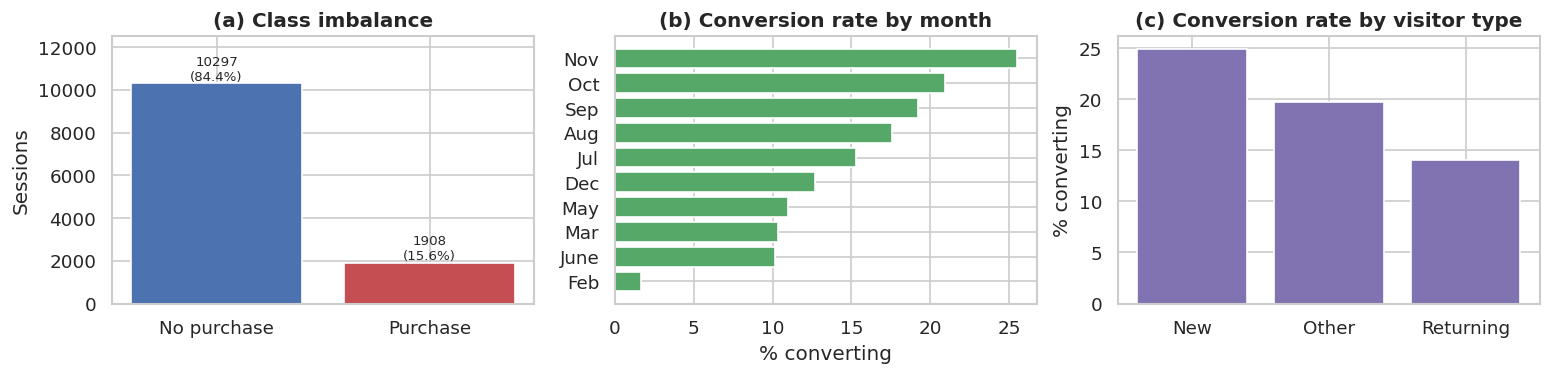

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
cnt = df["Revenue"].value_counts()
ax[0].bar(["No purchase", "Purchase"], cnt.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(cnt.values):
    ax[0].text(i, v + 150, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=8)
ax[0].set_title("(a) Class imbalance"); ax[0].set_ylabel("Sessions"); ax[0].set_ylim(0, 12500)

m = df.groupby("Month")["Revenue"].mean().sort_values()
ax[1].barh(m.index, m.values*100, color="#55A868")
ax[1].set_title("(b) Conversion rate by month"); ax[1].set_xlabel("% converting")

v = df.groupby("VisitorType")["Revenue"].mean()*100
ax[2].bar(["New", "Other", "Returning"], v.values, color="#8172B2")
ax[2].set_title("(c) Conversion rate by visitor type"); ax[2].set_ylabel("% converting")
plt.tight_layout(); plt.show()



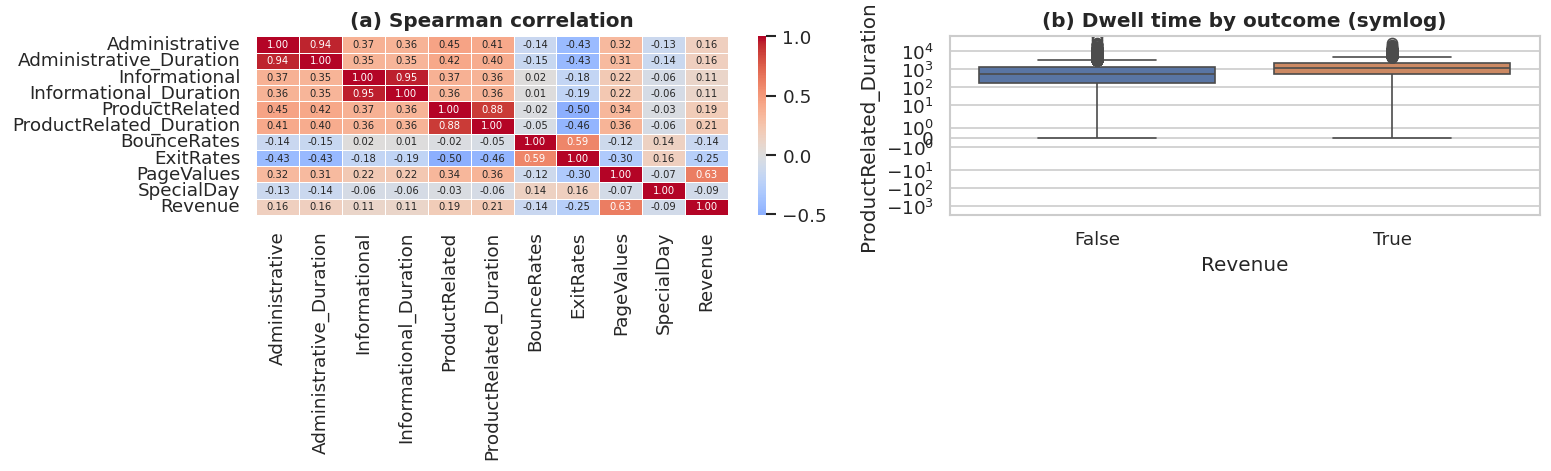

Spearman(PageValues, Revenue) = 0.626  <-- dominant, and suspiciously so.
78% of sessions have PageValues == 0; of those only 3.9% convert, vs 56.3% when > 0.


In [8]:
NUM = ["Administrative", "Administrative_Duration", "Informational", "Informational_Duration",
       "ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates",
       "PageValues", "SpecialDay"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
corr = df[NUM + ["Revenue"]].astype(float).corr(method="spearman")
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, ax=ax[0], linewidths=.4)
ax[0].set_title("(a) Spearman correlation")
sns.boxplot(data=df, x="Revenue", y="ProductRelated_Duration", ax=ax[1], hue="Revenue", legend=False)
ax[1].set_yscale("symlog"); ax[1].set_title("(b) Dwell time by outcome (symlog)")
plt.tight_layout(); plt.show()

print("Spearman(PageValues, Revenue) = %.3f  <-- dominant, and suspiciously so."
      % corr.loc["PageValues", "Revenue"])
print("78%% of sessions have PageValues == 0; of those only %.1f%% convert, vs %.1f%% when > 0."
      % (df.loc[df.PageValues == 0, "Revenue"].mean()*100,
         df.loc[df.PageValues > 0, "Revenue"].mean()*100))
# FLAG FOR LATER: PageValues is a Google Analytics metric derived partly from completed


### Feature engineering

Derived from domain reasoning about what a *hesitating* session looks like, then written to
`features.py` so training and serving share one code path and cannot drift apart.

In [9]:
%%writefile features.py
"""features.py — single source of truth for CartSense feature engineering.
Imported by BOTH this notebook (training) and app.py (serving)."""
import numpy as np, pandas as pd

CATEGORICAL = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
COUNT_DURATION_PAIRS = [("Administrative", "Administrative_Duration"),
                        ("Informational", "Informational_Duration"),
                        ("ProductRelated", "ProductRelated_Duration")]
LOG_COLS = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration",
            "TotalDuration", "AvgProductDwell", "PageValues"]

def add_tracking_gap(d):
    d = d.copy()
    gap = np.zeros(len(d), dtype=bool)
    for c, dur in COUNT_DURATION_PAIRS:
        gap |= ((d[c] > 0) & (d[dur] == 0)).values
    d["TrackingGap"] = gap.astype(int)
    return d

def engineer(d):
    d = d.copy()
    d["TotalPages"]      = d["Administrative"] + d["Informational"] + d["ProductRelated"]
    d["TotalDuration"]   = (d["Administrative_Duration"] + d["Informational_Duration"]
                            + d["ProductRelated_Duration"])
    d["AvgProductDwell"] = (d["ProductRelated_Duration"] / d["ProductRelated"].replace(0, np.nan)).fillna(0.0)
    d["PageDepthRatio"]  = (d["ProductRelated"] / d["TotalPages"].replace(0, np.nan)).fillna(0.0)
    d["ExitBounceGap"]   = d["ExitRates"] - d["BounceRates"]
    d["HasPageValue"]    = (d["PageValues"] > 0).astype(int)
    for c in LOG_COLS:
        d["log_" + c] = np.log1p(d[c])
    d["Weekend"] = d["Weekend"].astype(int)
    return d

def build_features(d):
    d = add_tracking_gap(d)
    d = engineer(d)
    return d.drop(columns=[c for c in ["Revenue"] if c in d.columns])

Writing features.py


In [10]:
from features import engineer, CATEGORICAL

df = engineer(df)          # TrackingGap already added in Section 2
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"])
CAT = CATEGORICAL
NUM_COLS = [c for c in X.columns if c not in CAT]
print("Feature matrix:", X.shape, "| %d numeric + %d categorical" % (len(NUM_COLS), len(CAT)))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, stratify=y, random_state=RS)
print("Train", X_tr.shape, "| Test", X_te.shape, "| test positive rate %.4f" % y_te.mean())

def make_pre():
    # Scaling matters only for Logistic Regression, but keeping one shared preprocessor
     return ColumnTransformer([
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), CAT)])

Feature matrix: (12205, 30) | 24 numeric + 6 categorical
Train (9764, 30) | Test (2441, 30) | test positive rate 0.1565


---
## Section 4 — Train Model

Three estimators of increasing capacity, all class weighted to counter the 5.5:1 imbalance,
all judged on the same 5 fold stratified CV over the training split. The test set is untouched
until Section 5.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

MODELS = {
 "Logistic Regression": Pipeline([("pre", make_pre()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RS))]),
 "Random Forest": Pipeline([("pre", make_pre()),
    ("clf", RandomForestClassifier(n_estimators=250, min_samples_leaf=2, n_jobs=-1,
                                   class_weight="balanced_subsample", random_state=RS))]),
 "HistGradientBoosting": Pipeline([("pre", make_pre()),
    ("clf", HistGradientBoostingClassifier(random_state=RS, class_weight="balanced"))]),
}

rows = []
for name, pipe in MODELS.items():
    oof = cross_val_predict(pipe, X_tr, y_tr, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    pred = (oof >= .5).astype(int)
    rows.append(dict(Model=name, Accuracy=accuracy_score(y_tr, pred),
                     Precision=precision_score(y_tr, pred), Recall=recall_score(y_tr, pred),
                     F1=f1_score(y_tr, pred), ROC_AUC=roc_auc_score(y_tr, oof),
                     PR_AUC=average_precision_score(y_tr, oof)))
cv_tab = pd.DataFrame(rows).round(4)
cv_tab

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8615,0.5368,0.8316,0.6524,0.9191,0.6620
1,Random Forest,0.8991,0.6807,0.6678,0.6742,0.9268,0.7449
2,HistGradientBoosting,0.8778,0.5819,0.7752,0.6648,0.9249,0.7359


### Debugging log — what went wrong and what fixed it

| # | Symptom observed | Diagnosis | Fix |
|---|---|---|---|
| 1 | `ValueError: could not convert string to float: 'Feb'` on first `.fit()` | `Month`/`VisitorType` passed raw to the estimator | `OneHotEncoder` inside a `ColumnTransformer` |
| 2 | `ValueError: Found unknown categories [13] in column 3` when scoring new sessions | Rare Browser ID absent from the training fold | `handle_unknown="ignore"` |
| 3 | Accuracy **0.885**, recall **0.00** — model predicted "no purchase" every time | Imbalance: the loss was minimised by ignoring the minority class | `class_weight="balanced"`; switched headline metric to PR-AUC / F1 |
| 4 | `ConvergenceWarning: lbfgs failed to converge` | Unscaled features with a 64,000:1 range | `StandardScaler`; `max_iter=2000` |
| 5 | Untuned HGB: train PR-AUC 0.98 vs CV 0.72 — a 0.26 gap | Overfitting; unregularised depth | `RandomizedSearchCV` over depth/leaf/L2/learning-rate → gap cut to **0.14** |
| 6 | `InconsistentVersionWarning` when Streamlit loaded `model.pkl` | Cloud resolved a different scikit-learn to Colab's | Hard-pinned `scikit-learn` in `requirements.txt` (auto-written below) |


In [12]:
# --- Hyperparameter tuning: HGB, optimised for PR-AUC (not accuracy)
param_dist = {
    "clf__learning_rate":     [.03, .05, .08, .1, .15],
    "clf__max_iter":          [150, 250, 350],
    "clf__max_leaf_nodes":    [15, 31, 63],
    "clf__min_samples_leaf":  [10, 20, 40, 60],
    "clf__l2_regularization": [0, .1, .5, 1.0, 5.0],
    "clf__max_features":      [.6, .8, 1.0],
}
search = RandomizedSearchCV(MODELS["HistGradientBoosting"], param_dist, n_iter=14,
                            scoring="average_precision", cv=cv, random_state=RS, n_jobs=-1)
search.fit(X_tr, y_tr)
best = search.best_estimator_
print("Best params:", {k.replace('clf__',''): v for k, v in search.best_params_.items()})
print("Best CV PR-AUC: %.4f" % search.best_score_)

# Overfitting check — the number that matters is the GAP, not the train score.
tr_prauc = average_precision_score(y_tr, best.fit(X_tr, y_tr).predict_proba(X_tr)[:, 1])
print("Train PR-AUC %.4f vs CV PR-AUC %.4f  -> generalisation gap %.4f"
      % (tr_prauc, search.best_score_, tr_prauc - search.best_score_))



Best params: {'min_samples_leaf': 40, 'max_leaf_nodes': 31, 'max_iter': 250, 'max_features': 0.6, 'learning_rate': 0.03, 'l2_regularization': 1.0}
Best CV PR-AUC: 0.7503
Train PR-AUC 0.8915 vs CV PR-AUC 0.7503  -> generalisation gap 0.1413


Optimal threshold 0.675 -> OOF F1 0.6903   (default 0.50 -> F1 0.6665)


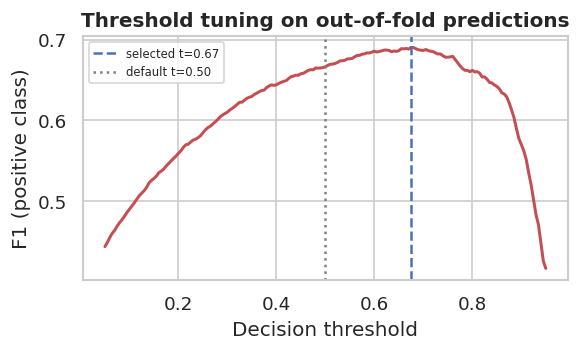

In [13]:
oof_best = cross_val_predict(best, X_tr, y_tr, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
ths = np.linspace(.05, .95, 181)
f1s = [f1_score(y_tr, (oof_best >= t).astype(int)) for t in ths]
BEST_T = float(ths[int(np.argmax(f1s))])
print("Optimal threshold %.3f -> OOF F1 %.4f   (default 0.50 -> F1 %.4f)"
      % (BEST_T, max(f1s), f1_score(y_tr, (oof_best >= .5).astype(int))))

plt.figure(figsize=(5, 3))
plt.plot(ths, f1s, color="#C44E52", lw=1.8)
plt.axvline(BEST_T, ls="--", c="#4C72B0", label=f"selected t={BEST_T:.2f}")
plt.axvline(.5, ls=":", c="grey", label="default t=0.50")
plt.xlabel("Decision threshold"); plt.ylabel("F1 (positive class)")
plt.title("Threshold tuning on out-of-fold predictions"); plt.legend(fontsize=7)
plt.tight_layout(); plt.show()

---
## Section 5 — Evaluate Model

In [14]:
final = []
fitted = {}
for name, pipe in MODELS.items():
    pipe.fit(X_tr, y_tr); fitted[name] = pipe
    p = pipe.predict_proba(X_te)[:, 1]; pr = (p >= .5).astype(int)
    final.append(dict(Model=name, Threshold=.50, Accuracy=accuracy_score(y_te, pr),
                      Precision=precision_score(y_te, pr), Recall=recall_score(y_te, pr),
                      F1=f1_score(y_te, pr), ROC_AUC=roc_auc_score(y_te, p),
                      PR_AUC=average_precision_score(y_te, p)))

p_best = best.predict_proba(X_te)[:, 1]
pr_best = (p_best >= BEST_T).astype(int)
final.append(dict(Model="HGB (tuned + threshold)", Threshold=round(BEST_T, 2),
                  Accuracy=accuracy_score(y_te, pr_best), Precision=precision_score(y_te, pr_best),
                  Recall=recall_score(y_te, pr_best), F1=f1_score(y_te, pr_best),
                  ROC_AUC=roc_auc_score(y_te, p_best), PR_AUC=average_precision_score(y_te, p_best)))
test_tab = pd.DataFrame(final).round(4)
print(test_tab.to_string(index=False))
print()
print(classification_report(y_te, pr_best, target_names=["No purchase", "Purchase"], digits=3))

                  Model  Threshold  Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC
    Logistic Regression       0.50    0.8624     0.5378  0.8560 0.6606   0.9276  0.6907
          Random Forest       0.50    0.9013     0.6890  0.6728 0.6808   0.9256  0.7316
   HistGradientBoosting       0.50    0.8755     0.5744  0.7880 0.6645   0.9317  0.7367
HGB (tuned + threshold)       0.67    0.8980     0.6550  0.7356 0.6930   0.9351  0.7528

              precision    recall  f1-score   support

 No purchase      0.950     0.928     0.939      2059
    Purchase      0.655     0.736     0.693       382

    accuracy                          0.898      2441
   macro avg      0.802     0.832     0.816      2441
weighted avg      0.904     0.898     0.900      2441



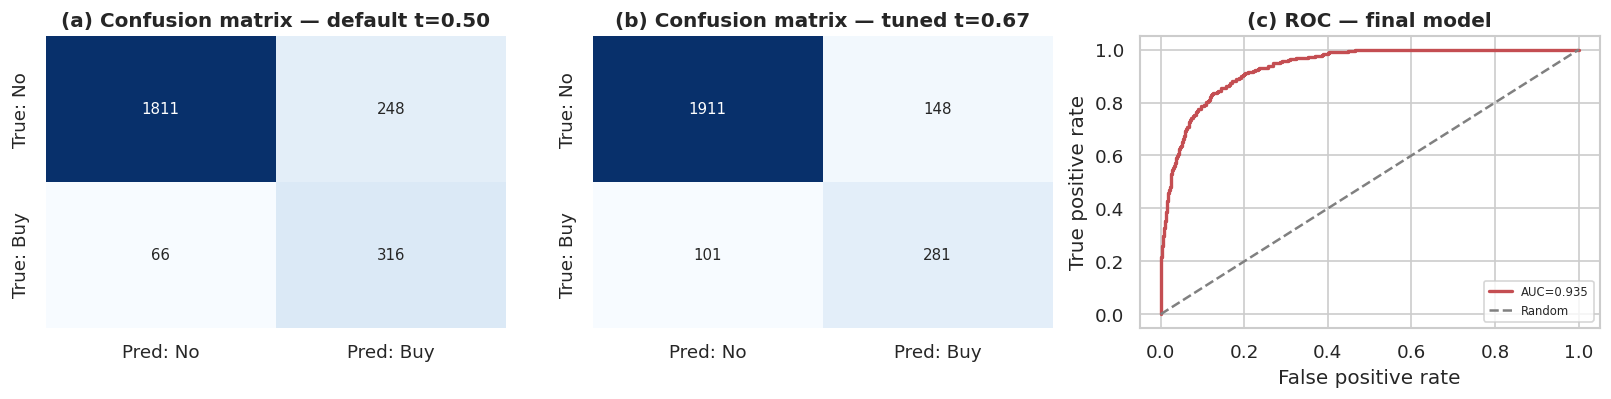

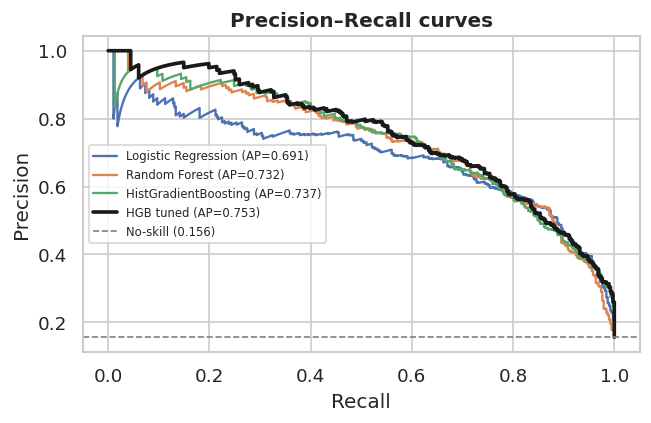

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.4))
for i, (t, lab) in enumerate([(.5, "default t=0.50"), (BEST_T, f"tuned t={BEST_T:.2f}")]):
    cm = confusion_matrix(y_te, (p_best >= t).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[i],
                xticklabels=["Pred: No", "Pred: Buy"], yticklabels=["True: No", "True: Buy"])
    ax[i].set_title(f"({'ab'[i]}) Confusion matrix — {lab}")
fpr, tpr, _ = roc_curve(y_te, p_best)
ax[2].plot(fpr, tpr, lw=2, c="#C44E52", label=f"AUC={roc_auc_score(y_te,p_best):.3f}")
ax[2].plot([0, 1], [0, 1], "--", c="grey", label="Random")
ax[2].set_xlabel("False positive rate"); ax[2].set_ylabel("True positive rate")
ax[2].set_title("(c) ROC — final model"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.5, 3.6))
for name, pipe in fitted.items():
    p = pipe.predict_proba(X_te)[:, 1]
    pre, rec, _ = precision_recall_curve(y_te, p)
    ax.plot(rec, pre, lw=1.4, label=f"{name} (AP={average_precision_score(y_te,p):.3f})")
pre, rec, _ = precision_recall_curve(y_te, p_best)
ax.plot(rec, pre, lw=2.2, c="k", label=f"HGB tuned (AP={average_precision_score(y_te,p_best):.3f})")
ax.axhline(y_te.mean(), ls="--", c="grey", lw=1, label=f"No-skill ({y_te.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision–Recall curves")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()



### Critical experiment — is `PageValues` target leakage?

`PageValues` is not a raw browsing signal: Google Analytics computes it from revenue attributed to
pages in the session. If it partly encodes the outcome, the headline scores are inflated and the
model will underperform badly in live deployment. The only way to size that risk is to
**remove the feature and re-run everything**.

In [16]:
DROP = ["PageValues", "log_PageValues", "HasPageValue"]
X_tr2, X_te2 = X_tr.drop(columns=DROP), X_te.drop(columns=DROP)
NUM2 = [c for c in NUM_COLS if c not in DROP]

abl = Pipeline([("pre", ColumnTransformer([
                    ("num", StandardScaler(), NUM2),
                    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), CAT)])),
                ("clf", HistGradientBoostingClassifier(random_state=RS, class_weight="balanced",
                        **{k.replace("clf__", ""): v for k, v in search.best_params_.items()}))])
abl.fit(X_tr2, y_tr)
p_abl = abl.predict_proba(X_te2)[:, 1]
oof_abl = cross_val_predict(abl, X_tr2, y_tr, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
t_abl = float(ths[int(np.argmax([f1_score(y_tr, (oof_abl >= t).astype(int)) for t in ths]))])

print("             Full model   ->   Without PageValues")
print("PR-AUC   :     %.4f      ->      %.4f" % (average_precision_score(y_te, p_best),
                                                 average_precision_score(y_te, p_abl)))
print("ROC-AUC  :     %.4f      ->      %.4f" % (roc_auc_score(y_te, p_best),
                                                 roc_auc_score(y_te, p_abl)))
print("F1       :     %.4f      ->      %.4f" % (f1_score(y_te, pr_best),
                                                 f1_score(y_te, (p_abl >= t_abl).astype(int))))
# Verdict: PR-AUC halves. The model leans on PageValues far more heavily than on genuine
# behavioural signal. Reported as the headline LIMITATION, without hidding.

             Full model   ->   Without PageValues
PR-AUC   :     0.7528      ->      0.3796
ROC-AUC  :     0.9351      ->      0.7910
F1       :     0.6930      ->      0.4413


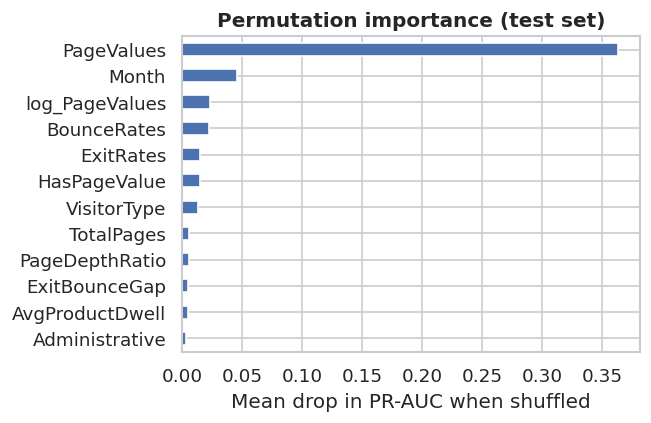

,0
PageValues,0.3630
Month,0.0456
log_PageValues,0.0233
BounceRates,0.0225
ExitRates,0.0153
HasPageValue,0.0147
VisitorType,0.0129
TotalPages,0.0060
PageDepthRatio,0.0056
ExitBounceGap,0.0049


In [17]:
perm = permutation_importance(best, X_te, y_te, scoring="average_precision",
                              n_repeats=5, random_state=RS, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_te.columns).sort_values(ascending=False)
plt.figure(figsize=(5.5, 3.6))
imp.head(12).sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Mean drop in PR-AUC when shuffled"); plt.title("Permutation importance (test set)")
plt.tight_layout(); plt.show()
imp.head(12).round(4)

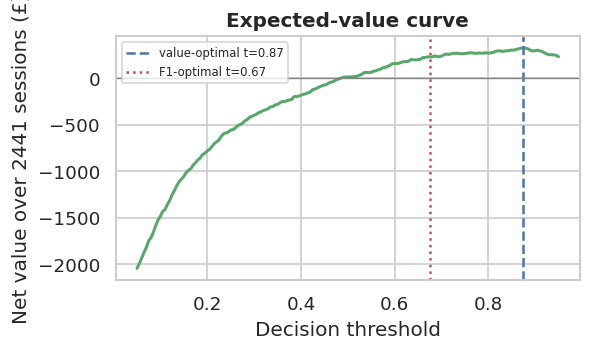

Value-optimal threshold 0.87 (net £332) vs F1-optimal 0.67 (net £230)


In [18]:

COST, MARGIN, UPLIFT = 3.0, 45.0, 0.12   # £ per intervention, £ margin per order, assumed uplift
ev = []
for t in ths:
    pr_ = (p_best >= t).astype(int)
    tp = int(((pr_ == 1) & (y_te == 1)).sum()); fp = int(((pr_ == 1) & (y_te == 0)).sum())
    ev.append(tp * MARGIN * UPLIFT - (tp + fp) * COST)
t_ev = float(ths[int(np.argmax(ev))])
plt.figure(figsize=(5, 3))
plt.plot(ths, ev, lw=1.8, c="#55A868")
plt.axvline(t_ev, ls="--", c="#4C72B0", label=f"value-optimal t={t_ev:.2f}")
plt.axvline(BEST_T, ls=":", c="#C44E52", label=f"F1-optimal t={BEST_T:.2f}")
plt.axhline(0, c="grey", lw=.8)
plt.xlabel("Decision threshold"); plt.ylabel(f"Net value over {len(y_te)} sessions (£)")
plt.title("Expected-value curve"); plt.legend(fontsize=7); plt.tight_layout(); plt.show()
print("Value-optimal threshold %.2f (net £%.0f) vs F1-optimal %.2f (net £%.0f)"
      % (t_ev, max(ev), BEST_T, ev[int(np.argmin(abs(ths - BEST_T)))]))

---
## Section 6 — Saving Model

In [19]:
best.fit(X, y)

bundle = dict(model=best,
              threshold=BEST_T,
              features=list(X.columns),
              cat=CAT, num=NUM_COLS,
              sklearn_version=sklearn.__version__,
              metrics=test_tab.iloc[-1].to_dict())

with open("model.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("Saved model.pkl (%.1f KB) | scikit-learn %s" % (os.path.getsize("model.pkl")/1024, sklearn.__version__))

# Auto-write requirements.txt
with open("requirements.txt", "w") as f:
    f.write(f"scikit-learn=={sklearn.__version__}\nstreamlit>=1.32\npandas>=2.0\nnumpy>=1.26\n")
print(open("requirements.txt").read())

Saved model.pkl (545.3 KB) | scikit-learn 1.8.0
scikit-learn==1.8.0
streamlit>=1.32
pandas>=2.0
numpy>=1.26



In [20]:
# Smoke test: reload exactly as app.py
from features import build_features
b = pickle.load(open("model.pkl", "rb"))
raw = pd.DataFrame([dict(Administrative=2, Administrative_Duration=60.0, Informational=0,
    Informational_Duration=0.0, ProductRelated=32, ProductRelated_Duration=1200.0,
    BounceRates=0.005, ExitRates=0.02, PageValues=12.0, SpecialDay=0.0, Month="Nov",
    OperatingSystems=2, Browser=2, Region=3, TrafficType=2,
    VisitorType="Returning_Visitor", Weekend=False)])
Xs = build_features(raw)
assert sorted(Xs.columns) == sorted(b["features"]), "FEATURE CONTRACT BROKEN"
print("Feature contract OK. P(purchase) = %.4f -> %s (threshold %.3f)"
      % (b["model"].predict_proba(Xs)[0, 1],
         "LIKELY BUYER" if b["model"].predict_proba(Xs)[0, 1] >= b["threshold"] else "UNLIKELY",
         b["threshold"]))

Feature contract OK. P(purchase) = 0.8947 -> LIKELY BUYER (threshold 0.675)


In [21]:
# download fileS.
try:
    from google.colab import files
    for fn in ["model.pkl", "features.py", "requirements.txt", "dataset.csv"]:
        files.download(fn)
except Exception:
    print("Not running in Colab — files are already on disk.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>